# Cloud-Based Phishing URL Detection and Risk Assessment

### Mini Project – Cloud Computing

This project uses Google Colab as a cloud-based computational environment
to detect phishing URLs using machine learning.

Technologies:
- Python
- Google Colab
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Random Forest

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
import os

print(os.listdir('/content'))

['.config', 'phishing_url_dataset.csv', 'sample_data']


In [2]:
import pandas as pd

df = pd.read_csv('/content/phishing_url_dataset.csv')

print("✅ Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

✅ Dataset loaded successfully!
Number of rows: 2488
Number of columns: 14


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['url_length', 'valid_url', 'at_symbol', 'sensitive_words_count', 'path_length', 'isHttps', 'nb_dots', 'nb_hyphens', 'nb_and', 'nb_or', 'nb_www', 'nb_com', 'nb_underscore', 'target']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2488 entries, 0 to 2487
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   url_length             2488 non-null   int64
 1   valid_url              2488 non-null   int64
 2   at_symbol              2488 non-null   int64
 3   sensitive_words_count  2488 non-null   int64
 4   path_length            2488 non-null   int64
 5   isHttps                2488 non-null   int64
 6   nb_dots                2488 non-null   int64
 7   nb_hyphens             2488 non-null   int64
 8   nb_and                 2488 non-null   int64
 9   nb_or                  2488 non-null   int64
 10  nb_www                 2488 non-null   int64
 11  nb_com             

In [4]:
print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


First 5 rows:


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0



Last 5 rows:


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
2483,50,1,0,0,0,0,4,3,0,0,0,0,0,1
2484,74,1,0,0,0,1,5,0,0,0,0,0,0,1
2485,74,1,0,0,0,1,5,0,0,0,0,0,1,1
2486,74,1,0,0,0,1,5,0,0,0,0,0,0,1
2487,74,1,0,0,0,1,5,0,0,0,0,0,0,1


In [5]:
print(df.dtypes)

url_length               int64
valid_url                int64
at_symbol                int64
sensitive_words_count    int64
path_length              int64
isHttps                  int64
nb_dots                  int64
nb_hyphens               int64
nb_and                   int64
nb_or                    int64
nb_www                   int64
nb_com                   int64
nb_underscore            int64
target                   int64
dtype: object


In [6]:
for column in df.columns:
    print("\nColumn:", column)
    print(df[column].value_counts().head(10))


Column: url_length
url_length
73    718
74    411
75    148
69     68
24     51
26     47
27     42
22     42
23     41
25     40
Name: count, dtype: int64

Column: valid_url
valid_url
0    1791
1     697
Name: count, dtype: int64

Column: at_symbol
at_symbol
0    2482
1       4
8       1
9       1
Name: count, dtype: int64

Column: sensitive_words_count
sensitive_words_count
0    1934
1     532
2      20
3       2
Name: count, dtype: int64

Column: path_length
path_length
0     1043
26     190
22     148
1      135
47      58
44      49
49      41
51      40
46      40
48      39
Name: count, dtype: int64

Column: isHttps
isHttps
0    1424
1    1064
Name: count, dtype: int64

Column: nb_dots
nb_dots
5    850
2    365
1    302
9    223
6    214
8    190
4    172
7     95
3     62
0      7
Name: count, dtype: int64

Column: nb_hyphens
nb_hyphens
0     1810
1      318
2      154
4       74
3       73
5       36
6       14
7        6
10       3
Name: count, dtype: int64

Column: nb_and
n

In [7]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
url_length               0
valid_url                0
at_symbol                0
sensitive_words_count    0
path_length              0
isHttps                  0
nb_dots                  0
nb_hyphens               0
nb_and                   0
nb_or                    0
nb_www                   0
nb_com                   0
nb_underscore            0
target                   0
dtype: int64

Number of duplicate rows: 1134


In [8]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1354, 14)


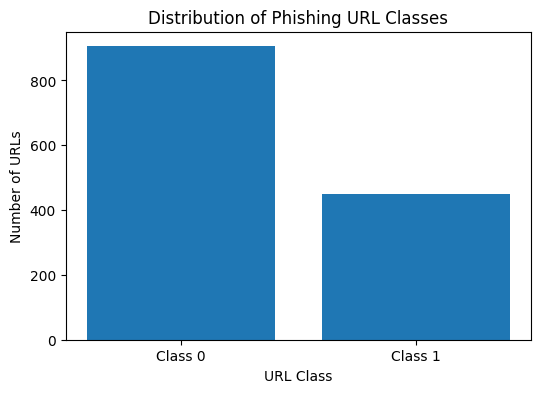

In [9]:
import matplotlib.pyplot as plt

target_counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ['Class 0', 'Class 1'],
    target_counts.values
)

plt.xlabel("URL Class")
plt.ylabel("Number of URLs")
plt.title("Distribution of Phishing URL Classes")

plt.show()

In [10]:
# Separate input features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1354, 13)
Target shape: (1354,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1083
Testing samples: 271


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 78.6 %


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       181
           1       0.70      0.62      0.66        90

    accuracy                           0.79       271
   macro avg       0.76      0.74      0.75       271
weighted avg       0.78      0.79      0.78       271



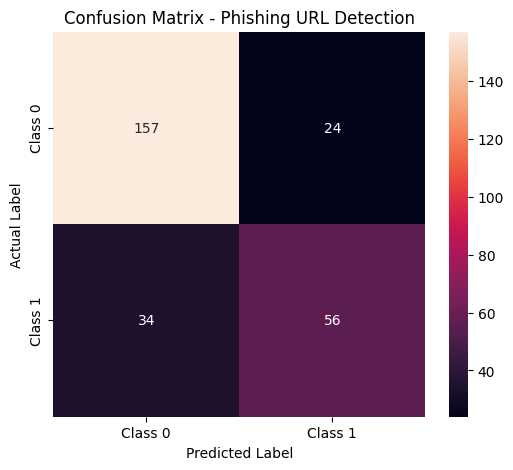

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Phishing URL Detection')

plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.8229


In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

,Feature,Importance
0,url_length,0.225257
4,path_length,0.173901
1,valid_url,0.164706
6,nb_dots,0.120558
7,nb_hyphens,0.092994
10,nb_www,0.046378
5,isHttps,0.040351
9,nb_or,0.039301
3,sensitive_words_count,0.034242
11,nb_com,0.031184


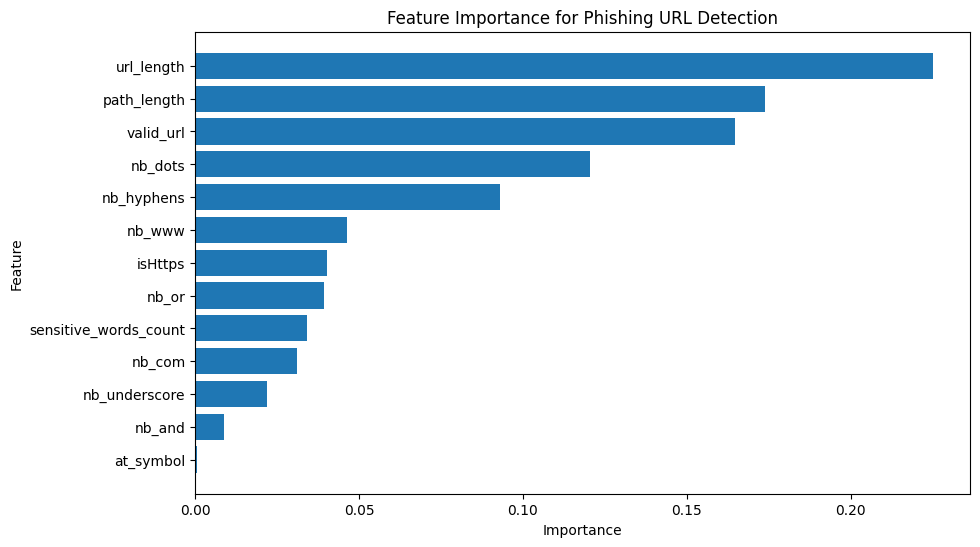

In [19]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Phishing URL Detection')

plt.gca().invert_yaxis()

plt.show()

In [20]:
print(df.groupby('target').mean(numeric_only=True))

        url_length  valid_url  at_symbol  sensitive_words_count  path_length  \
target                                                                         
0        49.567956   0.014365   0.022099               0.107182    16.317127   
1        56.282851   0.331849   0.002227               0.238307    13.456570   

         isHttps   nb_dots  nb_hyphens    nb_and     nb_or    nb_www  \
target                                                                 
0       0.246409  3.744751    0.644199  0.032044  0.261878  0.375691   
1       0.340757  4.374165    1.040089  0.011136  0.262806  0.135857   

          nb_com  nb_underscore  
target                           
0       0.698343       0.183425  
1       0.630290       0.095768  


In [21]:
print(df[['target', 'url_length', 'valid_url', 'sensitive_words_count', 'isHttps']].groupby('target').mean())

        url_length  valid_url  sensitive_words_count   isHttps
target                                                        
0        49.567956   0.014365               0.107182  0.246409
1        56.282851   0.331849               0.238307  0.340757


In [22]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
url_length               0
valid_url                0
at_symbol                0
sensitive_words_count    0
path_length              0
isHttps                  0
nb_dots                  0
nb_hyphens               0
nb_and                   0
nb_or                    0
nb_www                   0
nb_com                   0
nb_underscore            0
target                   0
dtype: int64

Duplicate rows:
0


In [23]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (1354, 14)


In [24]:
X = df.drop('target', axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1354, 13)
y shape: (1354,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1083, 13)
Testing data: (271, 13)


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [27]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 78.6 %


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       181
           1       0.70      0.62      0.66        90

    accuracy                           0.79       271
   macro avg       0.76      0.74      0.75       271
weighted avg       0.78      0.79      0.78       271



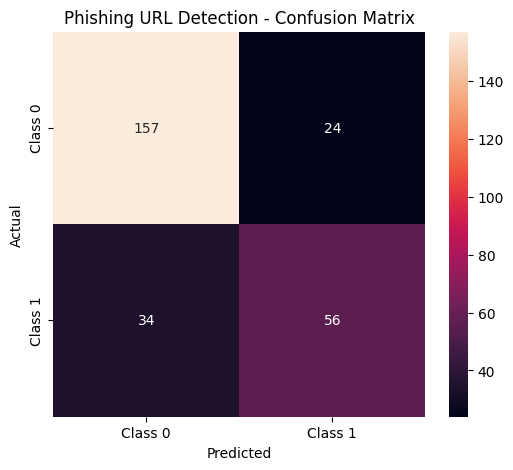

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Phishing URL Detection - Confusion Matrix")

plt.show()

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance)

,Feature,Importance
0,url_length,0.225257
4,path_length,0.173901
1,valid_url,0.164706
6,nb_dots,0.120558
7,nb_hyphens,0.092994
10,nb_www,0.046378
5,isHttps,0.040351
9,nb_or,0.039301
3,sensitive_words_count,0.034242
11,nb_com,0.031184


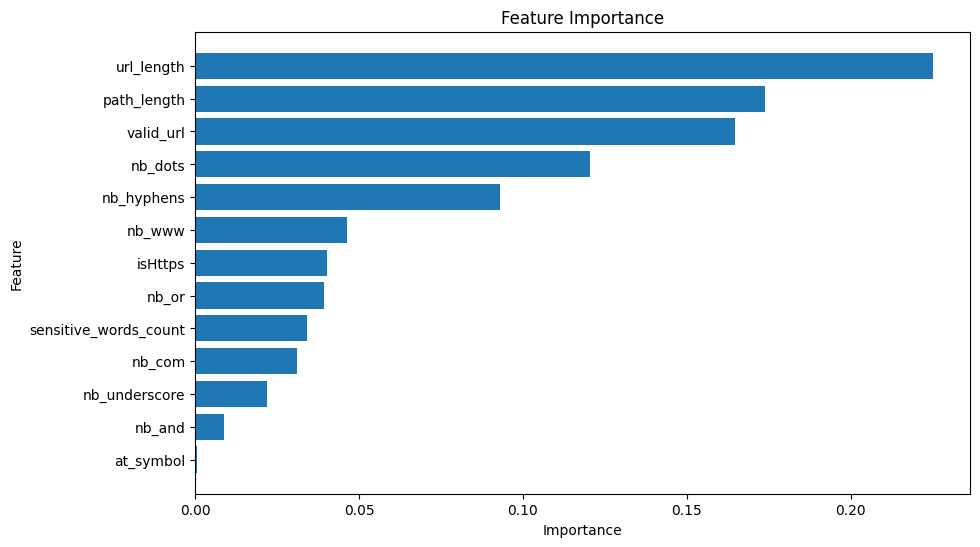

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [32]:
# ============================================
# STEP 7: DATA CLEANING
# ============================================

print("Original dataset shape:", df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove duplicate rows
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

df = df.drop_duplicates().reset_index(drop=True)

print("\nDataset shape after cleaning:", df.shape)

Original dataset shape: (1354, 14)

Missing values:
url_length               0
valid_url                0
at_symbol                0
sensitive_words_count    0
path_length              0
isHttps                  0
nb_dots                  0
nb_hyphens               0
nb_and                   0
nb_or                    0
nb_www                   0
nb_com                   0
nb_underscore            0
target                   0
dtype: int64

Duplicate rows: 0

Dataset shape after cleaning: (1354, 14)


In [33]:
# ============================================
# STEP 8: TARGET DISTRIBUTION
# ============================================

print("Target distribution:")
print(df['target'].value_counts())

print("\nPercentage distribution:")
print(df['target'].value_counts(normalize=True) * 100)

Target distribution:
target
0    905
1    449
Name: count, dtype: int64

Percentage distribution:
target
0    66.838996
1    33.161004
Name: proportion, dtype: float64


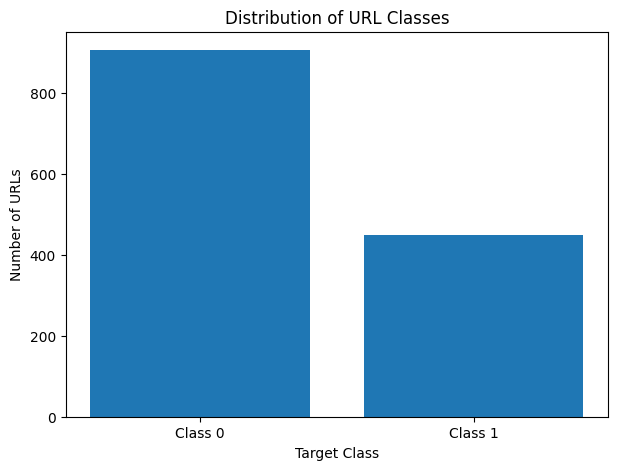

In [34]:
import matplotlib.pyplot as plt

counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(['Class 0', 'Class 1'], counts.values)

plt.xlabel("Target Class")
plt.ylabel("Number of URLs")
plt.title("Distribution of URL Classes")

plt.show()

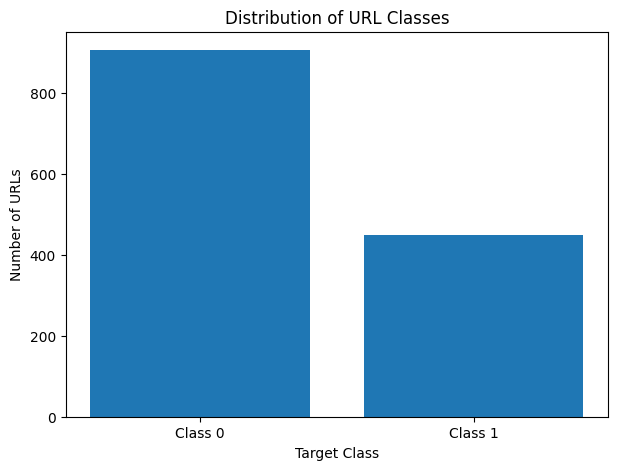

In [35]:
import matplotlib.pyplot as plt

counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(['Class 0', 'Class 1'], counts.values)

plt.xlabel("Target Class")
plt.ylabel("Number of URLs")
plt.title("Distribution of URL Classes")

plt.show()

In [36]:
# ============================================
# STEP 9: FEATURE / TARGET SEPARATION
# ============================================

X = df.drop('target', axis=1)
y = df['target']

print("Input features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Number of samples:", X.shape[0])

Input features:
['url_length', 'valid_url', 'at_symbol', 'sensitive_words_count', 'path_length', 'isHttps', 'nb_dots', 'nb_hyphens', 'nb_and', 'nb_or', 'nb_www', 'nb_com', 'nb_underscore']

Number of features: 13
Number of samples: 1354


In [37]:
# ============================================
# STEP 10: TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1083
Testing samples: 271


In [38]:
# ============================================
# STEP 11: RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [39]:
# ============================================
# STEP 12: PREDICTION
# ============================================

y_pred = model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1]


In [40]:
# ============================================
# STEP 13: MODEL ACCURACY
# ============================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("====================================")
print("       MODEL PERFORMANCE")
print("====================================")
print("Accuracy:", round(accuracy * 100, 2), "%")

       MODEL PERFORMANCE
Accuracy: 78.6 %


In [41]:
# ============================================
# STEP 14: CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       181
           1       0.70      0.62      0.66        90

    accuracy                           0.79       271
   macro avg       0.76      0.74      0.75       271
weighted avg       0.78      0.79      0.78       271



Confusion Matrix:
[[157  24]
 [ 34  56]]


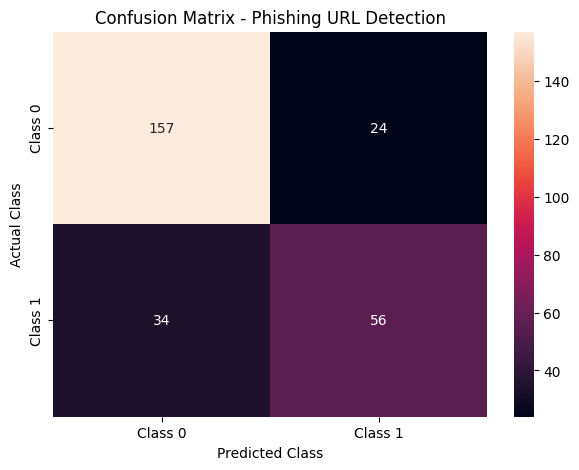

In [42]:
# ============================================
# STEP 15: CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Phishing URL Detection")

plt.show()

In [43]:
# ============================================
# STEP 16: ROC-AUC
# ============================================

from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.8229


In [44]:
# ============================================
# STEP 17: FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

,Feature,Importance
0,url_length,0.225257
4,path_length,0.173901
1,valid_url,0.164706
6,nb_dots,0.120558
7,nb_hyphens,0.092994
10,nb_www,0.046378
5,isHttps,0.040351
9,nb_or,0.039301
3,sensitive_words_count,0.034242
11,nb_com,0.031184


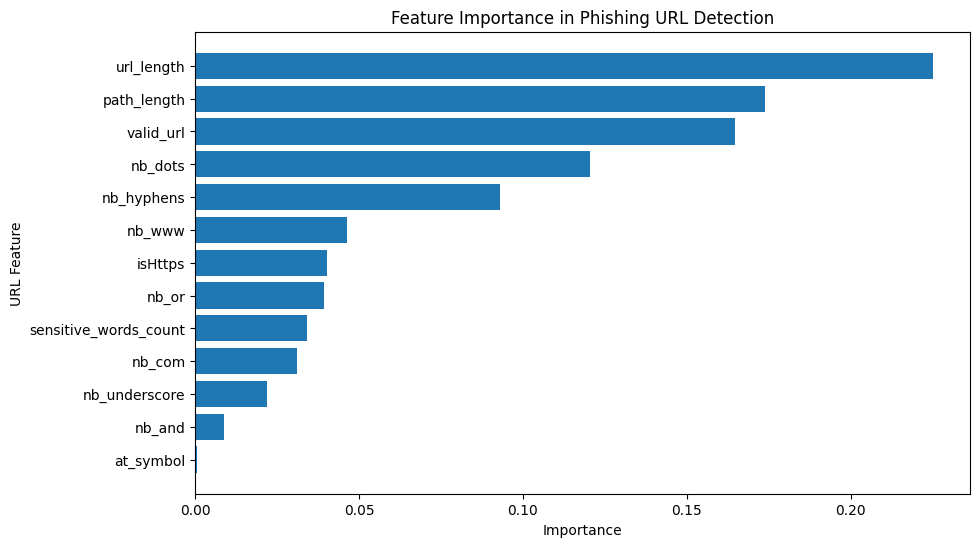

In [45]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("URL Feature")
plt.title("Feature Importance in Phishing URL Detection")

plt.gca().invert_yaxis()

plt.show()

In [46]:
# ============================================
# STEP 18: URL FEATURE EXTRACTION
# ============================================

import re
from urllib.parse import urlparse

def extract_url_features(url):

    url = str(url).strip()

    # Make sure URL has a scheme for parsing
    parsed_url = urlparse(
        url if '://' in url else 'http://' + url
    )

    domain = parsed_url.netloc
    path = parsed_url.path

    # Remove port number from domain
    domain_without_port = domain.split(':')[0]

    features = {}

    # 1. URL length
    features['url_length'] = len(url)

    # 2. Valid URL
    features['valid_url'] = 1 if parsed_url.netloc else 0

    # 3. @ symbol
    features['at_symbol'] = url.count('@')

    # 4. Sensitive words
    sensitive_words = [
        'login',
        'signin',
        'sign-in',
        'verify',
        'verification',
        'account',
        'password',
        'secure',
        'security',
        'update',
        'confirm',
        'bank',
        'wallet',
        'credential'
    ]

    features['sensitive_words_count'] = sum(
        word in url.lower()
        for word in sensitive_words
    )

    # 5. Path length
    features['path_length'] = len(path)

    # 6. HTTPS
    features['isHttps'] = 1 if parsed_url.scheme.lower() == 'https' else 0

    # 7. Number of dots
    features['nb_dots'] = url.count('.')

    # 8. Hyphens
    features['nb_hyphens'] = url.count('-')

    # 9. &
    features['nb_and'] = url.count('&')

    # 10. | / "or" character
    features['nb_or'] = url.count('|')

    # 11. www
    features['nb_www'] = url.lower().count('www')

    # 12. .com
    features['nb_com'] = url.lower().count('.com')

    # 13. underscore
    features['nb_underscore'] = url.count('_')

    # Return in exactly the same order as training data
    return pd.DataFrame([features])[X.columns]

In [47]:
test_url = "https://www.google.com"

features = extract_url_features(test_url)

display(features)

,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore
0,22,1,0,0,0,1,2,0,0,0,1,1,0


In [48]:
# ============================================
# STEP 19: PHISHING URL CHECKER
# ============================================

def check_phishing_url(url):

    # Extract features
    features = extract_url_features(url)

    # Prediction
    prediction = model.predict(features)[0]

    # Probability of class 1
    probability = model.predict_proba(features)[0][1]

    risk_score = probability * 100

    # Risk level
    if risk_score < 30:
        risk_level = "LOW"
    elif risk_score < 70:
        risk_level = "MEDIUM"
    else:
        risk_level = "HIGH"

    print("\n" + "=" * 55)
    print("        CLOUD-BASED PHISHING URL DETECTOR")
    print("=" * 55)

    print("\nURL:")
    print(url)

    print("\nPrediction:", prediction)
    print("Class-1 Probability:", round(risk_score, 2), "%")
    print("Risk Level:", risk_level)

    print("\n" + "=" * 55)

    return prediction, risk_score, risk_level

In [49]:
url = input("Enter a URL to analyze: ")

check_phishing_url(url)

Enter a URL to analyze: https://www.wikipedia.org

        CLOUD-BASED PHISHING URL DETECTOR

URL:
https://www.wikipedia.org

Prediction: 1
Class-1 Probability: 74.0 %
Risk Level: HIGH



(np.int64(1), np.float64(74.0), 'HIGH')

In [50]:
print("Target distribution:")
print(df['target'].value_counts())

print("\nAverage features by target:")
display(df.groupby('target').mean(numeric_only=True))

Target distribution:
target
0    905
1    449
Name: count, dtype: int64

Average features by target:


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore
target,,,,,,,,,,,,,
0,49.567956,0.014365,0.022099,0.107182,16.317127,0.246409,3.744751,0.644199,0.032044,0.261878,0.375691,0.698343,0.183425
1,56.282851,0.331849,0.002227,0.238307,13.456570,0.340757,4.374165,1.040089,0.011136,0.262806,0.135857,0.630290,0.095768


In [51]:
# Show some examples from each class
print("CLASS 0 EXAMPLES")
display(df[df['target'] == 0].head(10))

print("\nCLASS 1 EXAMPLES")
display(df[df['target'] == 1].head(10))

CLASS 0 EXAMPLES


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,1,0,1,0,1,0,0
3,36,0,0,0,0,1,4,0,0,0,0,0,0,0
4,72,0,0,0,48,0,5,2,0,0,0,1,0,0
5,65,0,0,0,40,0,6,0,0,0,1,2,0,0
6,72,0,0,0,48,0,5,0,0,0,0,1,0,0
7,22,0,0,0,0,0,1,0,0,1,0,1,0,0
8,22,0,0,0,1,0,1,0,0,0,0,1,0,0
9,72,0,0,0,51,0,5,0,0,0,0,1,0,0



CLASS 1 EXAMPLES


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
905,66,0,0,0,0,1,5,5,0,1,0,1,0,1
906,73,0,0,0,0,1,5,0,0,0,0,0,0,1
907,61,0,0,0,0,1,5,4,0,1,0,0,0,1
908,36,0,0,0,6,0,1,0,0,1,0,1,0,1
909,73,0,0,0,49,0,4,6,0,0,0,1,0,1
910,21,0,0,0,3,0,1,0,0,0,0,1,0,1
911,20,0,0,0,2,0,1,0,0,0,0,1,0,1
912,59,0,0,0,0,1,5,5,0,1,0,0,0,1
913,73,0,0,0,48,0,4,3,0,0,0,1,0,1
914,64,0,0,0,0,1,5,4,0,1,0,0,0,1


In [52]:
wiki_url = "https://www.wikipedia.org"

wiki_features = extract_url_features(wiki_url)

display(wiki_features)

,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore
0,25,1,0,0,0,1,2,0,0,0,1,0,0


In [53]:
print(df.groupby('target').mean(numeric_only=True))

        url_length  valid_url  at_symbol  sensitive_words_count  path_length  \
target                                                                         
0        49.567956   0.014365   0.022099               0.107182    16.317127   
1        56.282851   0.331849   0.002227               0.238307    13.456570   

         isHttps   nb_dots  nb_hyphens    nb_and     nb_or    nb_www  \
target                                                                 
0       0.246409  3.744751    0.644199  0.032044  0.261878  0.375691   
1       0.340757  4.374165    1.040089  0.011136  0.262806  0.135857   

          nb_com  nb_underscore  
target                           
0       0.698343       0.183425  
1       0.630290       0.095768  


In [54]:
print("CLASS 0")
display(df[df['target'] == 0].head())

print("\nCLASS 1")
display(df[df['target'] == 1].head())

CLASS 0


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,1,0,1,0,1,0,0
3,36,0,0,0,0,1,4,0,0,0,0,0,0,0
4,72,0,0,0,48,0,5,2,0,0,0,1,0,0



CLASS 1


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
905,66,0,0,0,0,1,5,5,0,1,0,1,0,1
906,73,0,0,0,0,1,5,0,0,0,0,0,0,1
907,61,0,0,0,0,1,5,4,0,1,0,0,0,1
908,36,0,0,0,6,0,1,0,0,1,0,1,0,1
909,73,0,0,0,49,0,4,6,0,0,0,1,0,1


In [55]:
wiki_url = "https://www.wikipedia.org"

print("Features generated for Wikipedia:")
display(extract_url_features(wiki_url))

Features generated for Wikipedia:


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore
0,25,1,0,0,0,1,2,0,0,0,1,0,0
